# MALLORN Astronomical Classification Challenge

**Goal**: Identify Tidal Disruption Events (TDEs) — stars being torn apart by black holes — from simulated LSST light curves.

**Metric**: F1 Score (binary classification)

**Dataset**: 10,178 simulated LSST light curves constructed from real ZTF observations:
- 64 TDEs (target class)
- 727 Nuclear Supernovae
- 1,407 AGN

**Approach**:
1. Extract statistical and temporal features from multi-band light curves
2. Engineer domain-specific astronomical features (variability indices, color features, rise/decline rates)
3. Train an ensemble of LightGBM + XGBoost + ExtraTrees
4. Optimize threshold for F1 score

## 1. Setup & Imports

In [1]:
import os
import warnings
import numpy as np

# NumPy 2.0+ removed np.in1d; patch for older libs that still use it
if not hasattr(np, 'in1d'):
    np.in1d = np.isin

import pandas as pd
from scipy import stats
from scipy.stats import linregress, skew, kurtosis
from scipy.signal import find_peaks, lombscargle, savgol_filter
from scipy.integrate import trapezoid
from scipy.interpolate import interp1d
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from functools import reduce
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import xgboost as xgb

try:
    import catboost as cat
    from catboost import Pool
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print("CatBoost not installed, will skip CatBoost models")

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import Dataset, DataLoader
    HAS_TORCH = True
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch available, device: {DEVICE}")
except ImportError:
    HAS_TORCH = False
    print("PyTorch not installed, will skip DL models")

try:
    from astropy.cosmology import FlatLambdaCDM
    import astropy.units as u
    HAS_ASTROPY = True
    COSMO = FlatLambdaCDM(H0=70, Om0=0.3)
except ImportError:
    HAS_ASTROPY = False
    print("Astropy not installed, will skip luminosity features")

import random
import gc
import collections

warnings.filterwarnings("ignore")

# Auto-detect DATA_DIR: try relative first, then common absolute paths
_candidates = [
    os.path.join(os.getcwd(), "data"),
    os.path.join(os.path.dirname(os.path.abspath("__file__")), "data"),
    "/kaggle/input/mallorn-astronomical-data/mallorn-astronomical-classification-challenge",
    r"C:\Users\SG\Downloads\mallorn-astronomical-classification-challenge\data",
    "/Users/jackietan/Documents/workshop/academic/csc753m/kaggle_project/mallorn-astronomical-classification-challenge/data",
]
DATA_DIR = next((p for p in _candidates if os.path.exists(p)), _candidates[0])
print(f"DATA_DIR: {DATA_DIR}")

FILTERS = ["u", "g", "r", "i", "z", "y"]
N_SPLITS = 20
N_FOLDS = 5

PyTorch available, device: cuda
Astropy not installed, will skip luminosity features
DATA_DIR: C:\Users\SG\Downloads\mallorn-astronomical-classification-challenge\data


## 2. Load Data

In [2]:
# Load metadata
train_log = pd.read_csv(os.path.join(DATA_DIR, "train_log.csv"))
test_log = pd.read_csv(os.path.join(DATA_DIR, "test_log.csv"))

print(f"Train: {len(train_log)} objects ({train_log['target'].sum()} TDEs, {len(train_log) - train_log['target'].sum()} non-TDEs)")
print(f"Test:  {len(test_log)} objects")
print(f"\nTDE ratio: {train_log['target'].mean():.2%}")
train_log.head()

Train: 3043 objects (148 TDEs, 2895 non-TDEs)
Test:  7135 objects

TDE ratio: 4.86%


,object_id,Z,Z_err,EBV,SpecType,English Translation,split,target
0,Dornhoth_fervain_onodrim,3.0490,NaN,0.110,AGN,Trawn Folk (Dwarfs) + northern + Ents (people),split_01,0
1,Dornhoth_galadh_ylf,0.4324,NaN,0.058,SN II,Trawn Folk (Dwarfs) + tree + drinking vessel,split_01,0
2,Elrim_melethril_thul,0.4673,NaN,0.577,AGN,Elves + lover (fem.) + breath,split_01,0
3,Ithil_tobas_rodwen,0.6946,NaN,0.012,AGN,moon + roof + noble maiden,split_01,0
4,Mirion_adar_Druadan,0.4161,NaN,0.058,AGN,"jewel, Silmaril + father + Wild Man",split_01,0


In [3]:
# Load all light curves from 20 splits with SNR and Normalized Shape channel injection
def load_and_augment_lightcurves(data_dir, split_range, filename):
    """Load light curves and inject SNR + Normalized Shape channels."""
    all_data = []
    for i in tqdm(split_range, desc=f"Loading {filename}"):
        fp = os.path.join(data_dir, f"split_{i:02d}", filename)
        if os.path.exists(fp):
            all_data.append(pd.read_csv(fp))
    df_raw = pd.concat(all_data, ignore_index=True)
    print(f"  Raw rows: {len(df_raw):,}")

    # Inject SNR channel (Flux / Flux_err as virtual bands)
    print("  Injecting SNR channels...")
    df_raw['snr'] = (df_raw['Flux'] / (df_raw['Flux_err'] + 1e-6)).fillna(0).replace([np.inf, -np.inf], 0)
    df_snr = df_raw.copy()
    df_snr['Filter'] = df_snr['Filter'] + '_snr'
    df_snr['Flux'] = df_snr['snr']
    df_raw.drop(columns=['snr'], inplace=True)
    df_snr.drop(columns=['snr'], inplace=True)
    df_base = pd.concat([df_raw, df_snr], ignore_index=True)

    # Inject Normalized Shape channel (Flux / Amplitude)
    print("  Injecting Normalized Shape channels...")
    group_stats = df_base.groupby(['object_id', 'Filter'])['Flux'].agg(['max', 'min'])
    group_stats['amplitude'] = group_stats['max'] - group_stats['min']
    df_norm = pd.merge(df_base, group_stats['amplitude'], on=['object_id', 'Filter'], how='left')
    df_norm['Flux'] = df_norm['Flux'] / (df_norm['amplitude'] + 1e-9)
    df_norm['Filter'] = df_norm['Filter'] + '_norm'
    df_norm.drop(columns=['amplitude'], inplace=True)
    df_final = pd.concat([df_base, df_norm], ignore_index=True)

    print(f"  Final rows: {len(df_final):,} ({len(df_final) // len(df_raw)}x augmented)")
    return df_raw, df_final  # Return both raw (for DL) and augmented (for features)

print("Loading train light curves...")
train_lc_raw, train_lc = load_and_augment_lightcurves(DATA_DIR, range(1, N_SPLITS + 1), "train_full_lightcurves.csv")
print("\nLoading test light curves...")
test_lc_raw, test_lc = load_and_augment_lightcurves(DATA_DIR, range(1, N_SPLITS + 1), "test_full_lightcurves.csv")

print(f"\nTrain LC rows (augmented): {len(train_lc):,}")
print(f"Test  LC rows (augmented): {len(test_lc):,}")

Loading train light curves...


Loading train_full_lightcurves.csv:   0%|          | 0/20 [00:00<?, ?it/s]

  Raw rows: 479,384
  Injecting SNR channels...
  Injecting Normalized Shape channels...
  Final rows: 1,917,536 (4x augmented)

Loading test light curves...


Loading test_full_lightcurves.csv:   0%|          | 0/20 [00:00<?, ?it/s]

  Raw rows: 1,145,125
  Injecting SNR channels...
  Injecting Normalized Shape channels...
  Final rows: 4,580,500 (4x augmented)

Train LC rows (augmented): 1,917,536
Test  LC rows (augmented): 4,580,500


## 3. Exploratory Data Analysis

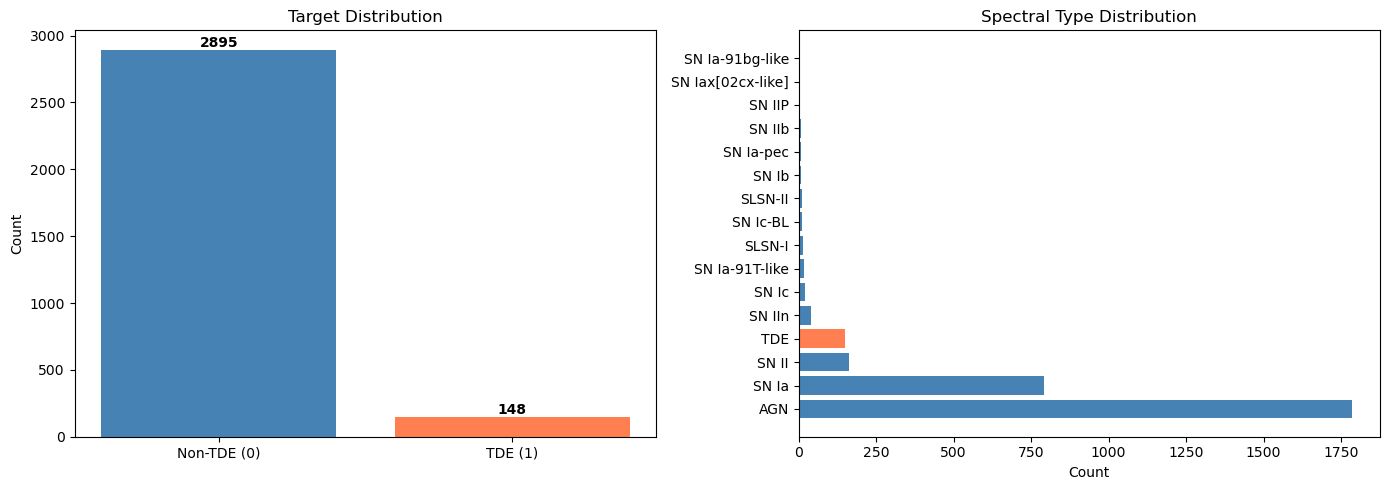

In [4]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target distribution
counts = train_log["target"].value_counts().sort_index()
axes[0].bar(["Non-TDE (0)", "TDE (1)"], counts.values, color=["steelblue", "coral"])
axes[0].set_title("Target Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha="center", fontweight="bold")

# SpecType distribution
spec_counts = train_log["SpecType"].value_counts()
colors = ["coral" if s == "TDE" else "steelblue" for s in spec_counts.index]
axes[1].barh(spec_counts.index, spec_counts.values, color=colors)
axes[1].set_title("Spectral Type Distribution")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

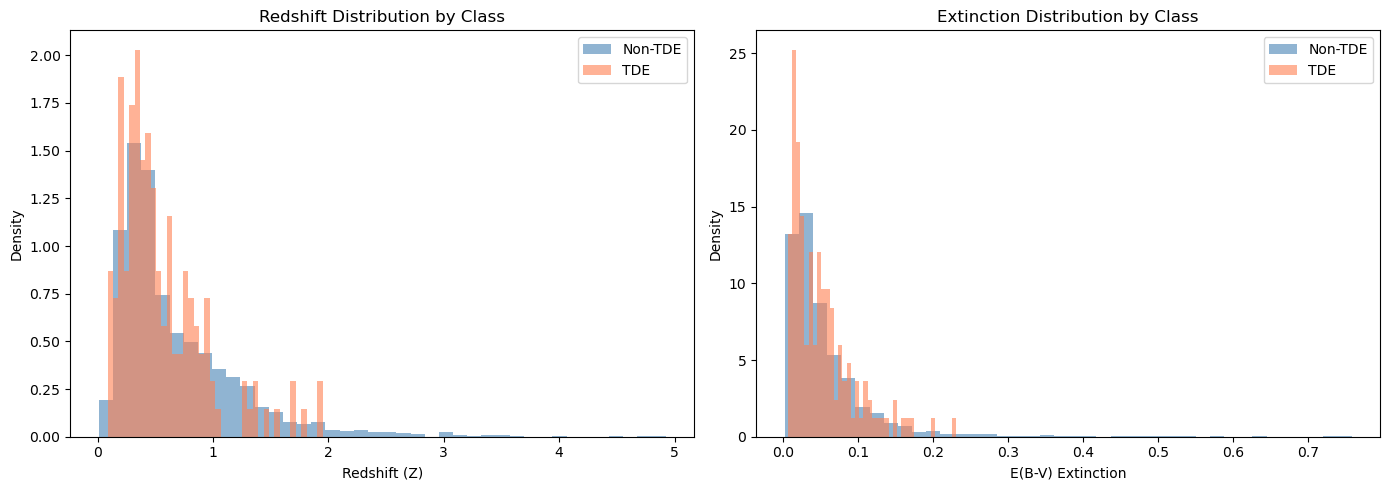

In [5]:
# Redshift distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, "steelblue", "Non-TDE"), (1, "coral", "TDE")]:
    subset = train_log[train_log["target"] == label]
    axes[0].hist(subset["Z"], bins=40, alpha=0.6, label=name, color=color, density=True)
axes[0].set_xlabel("Redshift (Z)")
axes[0].set_ylabel("Density")
axes[0].set_title("Redshift Distribution by Class")
axes[0].legend()

for label, color, name in [(0, "steelblue", "Non-TDE"), (1, "coral", "TDE")]:
    subset = train_log[train_log["target"] == label]
    axes[1].hist(subset["EBV"], bins=40, alpha=0.6, label=name, color=color, density=True)
axes[1].set_xlabel("E(B-V) Extinction")
axes[1].set_ylabel("Density")
axes[1].set_title("Extinction Distribution by Class")
axes[1].legend()

plt.tight_layout()
plt.show()

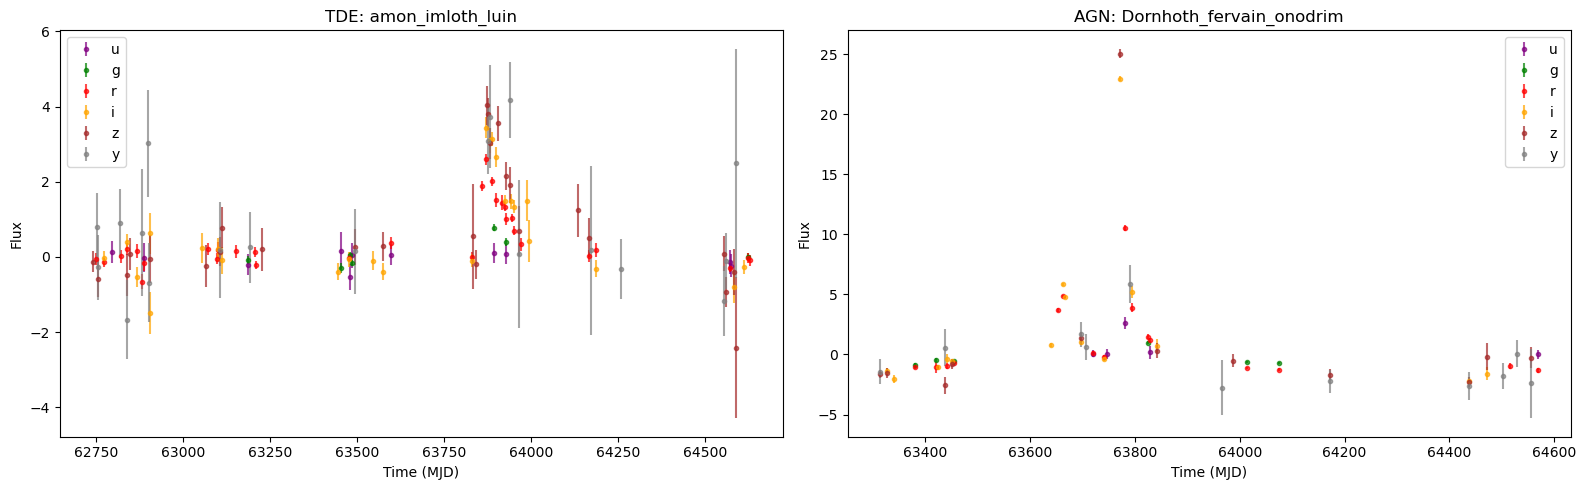

In [6]:
# Example light curves: TDE vs Non-TDE
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
filter_colors = {"u": "purple", "g": "green", "r": "red", "i": "orange", "z": "brown", "y": "gray"}

# TDE example
tde_ids = train_log[train_log["target"] == 1]["object_id"].values[:1]
for obj_id in tde_ids:
    obj_lc = train_lc[train_lc["object_id"] == obj_id]
    for filt in FILTERS:
        fdata = obj_lc[obj_lc["Filter"] == filt]
        if len(fdata) > 0:
            axes[0].errorbar(fdata["Time (MJD)"], fdata["Flux"], yerr=fdata["Flux_err"],
                           fmt="o", ms=3, label=filt, color=filter_colors[filt], alpha=0.7)
axes[0].set_title(f"TDE: {tde_ids[0]}")
axes[0].set_xlabel("Time (MJD)")
axes[0].set_ylabel("Flux")
axes[0].legend()

# Non-TDE example (AGN)
agn_ids = train_log[(train_log["target"] == 0) & (train_log["SpecType"] == "AGN")]["object_id"].values[:1]
for obj_id in agn_ids:
    obj_lc = train_lc[train_lc["object_id"] == obj_id]
    for filt in FILTERS:
        fdata = obj_lc[obj_lc["Filter"] == filt]
        if len(fdata) > 0:
            axes[1].errorbar(fdata["Time (MJD)"], fdata["Flux"], yerr=fdata["Flux_err"],
                           fmt="o", ms=3, label=filt, color=filter_colors[filt], alpha=0.7)
axes[1].set_title(f"AGN: {agn_ids[0]}")
axes[1].set_xlabel("Time (MJD)")
axes[1].set_ylabel("Flux")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Feature Engineering (Comprehensive Pipeline)

Adapted from the top solution. We extract features in many categories:
1. **Statistical features** — per-band basic stats (max, mean, std, count, timespan)
2. **Physical features** — TDE asymmetry ratio (rise vs decline)
3. **Resampled signal features** — FFT power spectrum, rolling std, skew
4. **Physical binning** — flux stats in 8 time bins around peak
5. **Color features** — flux differences between bands (including SNR/norm channels)
6. **Robust stacked features** — multi-band normalized stacking, FWHM, smoothness
7. **Advanced shape** — kurtosis, quantile ratios
8. **Gradient features** — max rise/decay rates, acceleration
9. **Power-law decay** — log-log regression on post-peak decay (TDE t^-5/3)
10. **Lomb-Scargle** — periodicity analysis for irregular time series
11. **Integral features** — area under curve for rise/decay phases
12. **Luminosity features** — flux corrected by luminosity distance
13. **Rest-frame kinematics** — time-dilation and distance corrected rates

In [7]:
# === Utility functions ===

def get_luminosity_distance(Z):
    """Get luminosity distance in parsecs from redshift."""
    if not HAS_ASTROPY or Z <= 0 or np.isnan(Z):
        return 1.0
    try:
        return COSMO.luminosity_distance(Z).to(u.pc).value
    except:
        return 1.0

def _resample_lightcurve(time, flux, n_points=50):
    """Resample irregular time series to uniform grid."""
    if len(time) < 2:
        return np.zeros(n_points)
    try:
        f = interp1d(time, flux, kind='linear', fill_value='extrapolate')
        t_uniform = np.linspace(time.min(), time.max(), n_points)
        return f(t_uniform)
    except:
        return np.zeros(n_points)

def _safe_groupby_apply(df, groupby_cols, func):
    """Compatibility wrapper for groupby().apply() across pandas versions."""
    try:
        return df.groupby(groupby_cols).apply(func, include_groups=False).reset_index()
    except TypeError:
        return df.groupby(groupby_cols).apply(func).reset_index()

def _safe_groupby_apply_named(df, groupby_cols, func, result_name):
    """Compatibility wrapper for groupby().apply() returning a named Series."""
    try:
        return df.groupby(groupby_cols).apply(func, include_groups=False).reset_index(name=result_name)
    except TypeError:
        return df.groupby(groupby_cols).apply(func).reset_index(name=result_name)

# === Module 1: Per-band feature functions ===

def engineer_statistical_features(df_raw):
    """Basic per-band stats."""
    agg_funcs = {
        'max_flux': ('Flux', 'max'),
        'mean_flux': ('Flux', 'mean'),
        'std_flux': ('Flux', 'std'),
        'obs_count': ('Flux', 'count'),
        'time_span': ('Time (MJD)', lambda x: x.max() - x.min()),
    }
    return df_raw.groupby(['object_id', 'Filter']).agg(**agg_funcs).reset_index()

def _extract_resampled_features_per_group(group):
    """FFT and rolling features from resampled light curve."""
    if len(group) < 3:
        return pd.Series(0, index=['fft_power_mean', 'fft_dom_freq', 'roll_std_max', 'resampled_skew'])
    time = group['Time (MJD)'].values
    flux = group['Flux'].values
    flux_resampled = _resample_lightcurve(time, flux, n_points=50)
    flux_AC = flux_resampled - np.mean(flux_resampled)
    fft_coeffs = np.fft.rfft(flux_AC)
    power_spectrum = np.abs(fft_coeffs)**2
    return pd.Series({
        'fft_power_mean': np.mean(power_spectrum),
        'fft_dom_freq': np.argmax(power_spectrum),
        'roll_std_max': pd.Series(flux_resampled).rolling(5, center=True, min_periods=1).std().max(),
        'resampled_skew': skew(flux_resampled)
    })

def engineer_resampled_signal_features(df_raw):
    return _safe_groupby_apply(df_raw, ['object_id', 'Filter'], _extract_resampled_features_per_group)

def _extract_binned_features_per_group(group):
    """Flux stats in 8 time bins centered on peak."""
    bins = [-float('inf'), -365, -100, -30, 0, 30, 100, 365, float('inf')]
    n_bins = len(bins) - 1
    feature_names = []
    for i in range(n_bins):
        feature_names += [f'phys_bin_{i}_mean', f'phys_bin_{i}_skew']
    if len(group) < 4:
        return pd.Series(0.0, index=feature_names, dtype=float)
    t_peak = group.loc[group['Flux'].idxmax(), 'Time (MJD)']
    group = group.copy()
    group['dt'] = group['Time (MJD)'] - t_peak
    group['bin_id'] = pd.cut(group['dt'], bins=bins, labels=False)
    bin_stats = group.groupby('bin_id')['Flux'].agg(['mean', 'skew'])
    results = {}
    for i in range(n_bins):
        results[f'phys_bin_{i}_mean'] = bin_stats.loc[i, 'mean'] if i in bin_stats.index else 0.0
        results[f'phys_bin_{i}_skew'] = bin_stats.loc[i, 'skew'] if i in bin_stats.index else 0.0
    return pd.Series(results, dtype=float).fillna(0.0)

def engineer_physical_binning_features(df_raw):
    return _safe_groupby_apply(df_raw, ['object_id', 'Filter'], _extract_binned_features_per_group)

def _extract_advanced_shape_per_group(group):
    """Kurtosis and quantile ratios."""
    if len(group) < 5:
        return pd.Series(0.0, index=['flux_kurtosis', 'flux_q90_q50_ratio', 'flux_q100_q50_ratio'], dtype=float)
    flux = group['Flux'].values
    q100, q90, q50, q10 = np.max(flux), np.percentile(flux, 90), np.median(flux), np.percentile(flux, 10)
    div = q50 - q10 + 1e-6
    return pd.Series({
        'flux_kurtosis': kurtosis(flux, fisher=True),
        'flux_q90_q50_ratio': (q90 - q50) / div,
        'flux_q100_q50_ratio': (q100 - q50) / div
    })

def engineer_advanced_shape_features(df_raw):
    return _safe_groupby_apply(df_raw, ['object_id', 'Filter'], _extract_advanced_shape_per_group)

def _extract_gradient_features_per_group(group):
    """Max rise/decay rates and acceleration."""
    if len(group) < 3:
        return pd.Series(0.0, index=['max_rise_rate', 'max_decay_rate', 'rise_decay_ratio', 'mean_acceleration'])
    flux_resampled = _resample_lightcurve(group['Time (MJD)'].values, group['Flux'].values, n_points=50)
    velocity = np.diff(flux_resampled)
    max_rise = np.max(velocity)
    max_decay = np.min(velocity)
    acceleration = np.diff(velocity)
    return pd.Series({
        'max_rise_rate': max_rise,
        'max_decay_rate': max_decay,
        'rise_decay_ratio': max_rise / (abs(max_decay) + 1e-6),
        'mean_acceleration': np.mean(np.abs(acceleration))
    })

def engineer_gradient_features(df_raw):
    return _safe_groupby_apply(df_raw, ['object_id', 'Filter'], _extract_gradient_features_per_group)

def _extract_powerlaw_features_per_group(group):
    """Power-law decay fit (TDE theory: t^-5/3)."""
    if len(group) < 4:
        return pd.Series({'powerlaw_alpha': 0.0, 'powerlaw_r_squared': 0.0})
    peak_idx = group['Flux'].idxmax()
    t_peak = group.loc[peak_idx, 'Time (MJD)']
    decay_df = group[(group['Time (MJD)'] > t_peak) & (group['Flux'] > 1e-6)].copy()
    if len(decay_df) < 3:
        return pd.Series({'powerlaw_alpha': 0.0, 'powerlaw_r_squared': 0.0})
    decay_df['log_dt'] = np.log(decay_df['Time (MJD)'] - t_peak)
    decay_df['log_flux'] = np.log(decay_df['Flux'])
    try:
        slope, _, r_value, _, _ = linregress(decay_df['log_dt'], decay_df['log_flux'])
        return pd.Series({'powerlaw_alpha': -slope, 'powerlaw_r_squared': r_value**2})
    except:
        return pd.Series({'powerlaw_alpha': 0.0, 'powerlaw_r_squared': 0.0})

def engineer_powerlaw_features(df_raw):
    return _safe_groupby_apply(df_raw, ['object_id', 'Filter'], _extract_powerlaw_features_per_group)

def _extract_lombscargle_features_per_group(group):
    """Lomb-Scargle periodogram for irregular time series."""
    default = pd.Series({'ls_power': 0.0, 'ls_freq': 0.0, 'ls_power_ratio': 0.0})
    if len(group) < 5 or np.std(group['Flux'].values) < 1e-9:
        return default
    try:
        time = group['Time (MJD)'].values
        flux_centered = group['Flux'].values - np.mean(group['Flux'].values)
        freqs = np.linspace(1/1000, 10, 250)
        power = lombscargle(time, flux_centered, freqs)
        if len(power) < 2:
            return default
        best_idx = np.argmax(power)
        best_power = power[best_idx]
        best_freq = freqs[best_idx]
        power[best_idx] = 0.0
        return pd.Series({
            'ls_power': np.nan_to_num(best_power),
            'ls_freq': np.nan_to_num(best_freq),
            'ls_power_ratio': np.nan_to_num(best_power / (np.max(power) + 1e-9))
        })
    except:
        return default

def engineer_lombscargle_features(df_raw):
    return _safe_groupby_apply(df_raw, ['object_id', 'Filter'], _extract_lombscargle_features_per_group)

def _extract_integral_features_per_group(group):
    """Area under curve for rise and decay phases."""
    default = pd.Series({'flux_integral': 0.0, 'rise_integral': 0.0,
                         'decay_integral': 0.0, 'integral_ratio': 0.0, 'integral_spread': 0.0})
    if len(group) < 3:
        return default
    time, flux = group['Time (MJD)'].values, group['Flux'].values
    flux_resampled = _resample_lightcurve(time, flux, n_points=50)
    t_resampled = np.linspace(time.min(), time.max(), 50)
    flux_pos = np.maximum(flux_resampled, 0)
    total = trapezoid(flux_pos, t_resampled)
    if total < 1e-9:
        return default
    max_idx = np.argmax(flux_pos)
    rise_int = trapezoid(flux_pos[:max_idx+1], t_resampled[:max_idx+1]) if max_idx > 0 else 0.0
    decay_int = trapezoid(flux_pos[max_idx:], t_resampled[max_idx:]) if max_idx < 49 else 0.0
    return pd.Series({
        'flux_integral': np.nan_to_num(total),
        'rise_integral': np.nan_to_num(rise_int),
        'decay_integral': np.nan_to_num(decay_int),
        'integral_ratio': np.nan_to_num((rise_int + 1e-9) / (decay_int + 1e-9)),
        'integral_spread': np.nan_to_num((rise_int + decay_int) / (total + 1e-9))
    })

def engineer_integral_features(df_raw):
    return _safe_groupby_apply(df_raw, ['object_id', 'Filter'], _extract_integral_features_per_group)

print("Feature engineering functions defined.")

Feature engineering functions defined.


In [8]:
# === Module 2: Global / cross-band feature functions ===

def _calculate_tde_asymmetry(group):
    """TDE asymmetry: ratio of rise time to decline time."""
    if len(group) < 2:
        return np.nan
    t_first, t_last = group['Time (MJD)'].min(), group['Time (MJD)'].max()
    t_peak = group.loc[group['Flux'].idxmax(), 'Time (MJD)']
    time_to_decline = t_last - t_peak
    return (t_peak - t_first) / (time_to_decline + 1e-6)

def engineer_physical_features(df_raw):
    return _safe_groupby_apply_named(df_raw, 'object_id', _calculate_tde_asymmetry, 'TDE_Asymmetry_Ratio')

def engineer_color_features(df_raw):
    """Color features: flux differences between band pairs (including augmented channels)."""
    df_work = df_raw.sort_values('Time (MJD)')
    suffixes = ['', '_snr', '_norm', '_snr_norm']
    pairs = [('u', 'g'), ('g', 'r'), ('r', 'i'), ('i', 'z'), ('z', 'y'),
             ('u', 'r'), ('g', 'i'), ('r', 'z'), ('u', 'y')]
    all_color_dfs = []
    for suffix in suffixes:
        for b1, b2 in pairs:
            f1, f2 = f"{b1}{suffix}", f"{b2}{suffix}"
            df1 = df_work[df_work['Filter'] == f1][['object_id', 'Time (MJD)', 'Flux']]
            df2 = df_work[df_work['Filter'] == f2][['object_id', 'Time (MJD)', 'Flux']]
            if df1.empty or df2.empty:
                continue
            matched = pd.merge_asof(
                df1, df2, on='Time (MJD)', by='object_id',
                direction='nearest', tolerance=1.0, suffixes=('_1', '_2')
            ).dropna(subset=['Flux_1', 'Flux_2'])
            if matched.empty:
                continue
            matched['diff'] = matched['Flux_1'] - matched['Flux_2']
            res = matched.groupby('object_id')['diff'].agg(['mean', 'std', 'skew', 'max', 'min'])
            res.columns = [f'color_{b1}_{b2}{suffix}_{c}' for c in res.columns]
            all_color_dfs.append(res)
    if not all_color_dfs:
        return pd.DataFrame({'object_id': df_raw['object_id'].unique()})
    df_final = pd.concat(all_color_dfs, axis=1).fillna(0.0).reset_index()
    df_final['object_id'] = df_final['object_id'].astype(df_raw['object_id'].dtype)
    return df_final

def _extract_robust_stacked_features(group):
    """Multi-band normalized stacking: FWHM, smoothness, rise/decay slopes."""
    feature_names = ['robust_rise_slope', 'robust_decay_slope', 'robust_fwhm', 'robust_skew', 'robust_smoothness']
    if len(group) < 5:
        return pd.Series(0, index=feature_names)
    n_points = 50
    stacked_flux = np.zeros(n_points)
    valid_count = 0
    for filter_name, sub in group.groupby('Filter'):
        if filter_name in ['g', 'r', 'i'] and len(sub) > 2:
            t, f = sub['Time (MJD)'].values, sub['Flux'].values
            if np.std(f) == 0:
                continue
            f_res = _resample_lightcurve(t, f, n_points)
            f_norm = f_res / (np.max(np.abs(f_res)) + 1e-6)
            stacked_flux += f_norm
            valid_count += 1
    if valid_count == 0:
        return pd.Series(0, index=feature_names)
    stacked_flux /= valid_count
    try:
        flux_smooth = savgol_filter(stacked_flux, window_length=11, polyorder=2)
    except:
        flux_smooth = stacked_flux
    f_max = np.max(flux_smooth)
    max_idx = np.argmax(flux_smooth)
    t_grid = np.linspace(0, 1, n_points)
    rise_slope = (f_max - flux_smooth[0]) / (t_grid[max_idx] - t_grid[0] + 1e-6) if max_idx > 0 else 0
    decay_slope = (flux_smooth[-1] - f_max) / (t_grid[-1] - t_grid[max_idx] + 1e-6) if max_idx < len(flux_smooth) - 1 else 0
    above_half = np.where(flux_smooth > f_max / 2.0)[0]
    fwhm = t_grid[above_half[-1]] - t_grid[above_half[0]] if len(above_half) > 1 else 0
    return pd.Series({
        'robust_rise_slope': rise_slope, 'robust_decay_slope': decay_slope,
        'robust_fwhm': fwhm, 'robust_skew': skew(flux_smooth), 'robust_smoothness': 1.0 / (np.sum((stacked_flux - flux_smooth)**2) + 1e-6)
    })

def engineer_robust_stacked_features(df_raw):
    return _safe_groupby_apply(df_raw, 'object_id', _extract_robust_stacked_features)

def engineer_luminosity_features(df_raw, df_log):
    """Convert flux to luminosity using redshift."""
    df_merged = pd.merge(df_raw, df_log[['object_id', 'Z']], on='object_id', how='left')
    df_merged['lum_dist_pc'] = df_merged['Z'].apply(get_luminosity_distance)
    df_merged['Luminosity'] = df_merged['Flux'] * (df_merged['lum_dist_pc']**2 + 1e-6)
    agg_funcs = {
        'L_max_flux': ('Luminosity', 'max'), 'L_mean_flux': ('Luminosity', 'mean'),
        'L_std_flux': ('Luminosity', 'std'), 'L_skew_flux': ('Luminosity', skew),
        'L_kurtosis_flux': ('Luminosity', kurtosis),
    }
    df_lum_bands = df_merged.groupby(['object_id', 'Filter']).agg(**agg_funcs).reset_index()
    df_lum_global = df_merged.groupby('object_id').agg(
        L_global_max=('Luminosity', 'max'), L_global_mean=('Luminosity', 'mean')
    ).reset_index()
    return df_lum_bands, df_lum_global

def engineer_rest_frame_kinematics(df_features, df_log):
    """Correct kinematic features for time dilation and luminosity distance."""
    df_phys = df_log[['object_id', 'Z']].copy()
    unique_zs = df_phys['Z'].unique()
    z_map = {z: get_luminosity_distance(z) for z in unique_zs}
    df_phys['dl_squared'] = df_phys['Z'].map(z_map) ** 2
    df_phys['time_dilation'] = 1 + df_phys['Z']
    df_work = pd.merge(df_features, df_phys, on='object_id', how='left')
    keywords = ['max_rise_rate', 'max_decay_rate', 'mean_acceleration', 'robust_rise_slope', 'robust_decay_slope']
    new_cols = {}
    for col in df_work.columns:
        if any(k in col for k in keywords) and 'L_' not in col:
            if 'acceleration' in col:
                factor = df_work['dl_squared'] * (df_work['time_dilation'] ** 2)
                prefix = 'L_acc_'
            else:
                factor = df_work['dl_squared'] * df_work['time_dilation']
                prefix = 'L_rate_'
            new_cols[f"{prefix}{col}"] = df_work[col] * factor
    df_kin = pd.DataFrame(new_cols)
    df_kin['object_id'] = df_features['object_id']
    return df_kin

# === Master pipeline ===

def merge_features(dfs_list, on_keys):
    if not dfs_list:
        return pd.DataFrame()
    return reduce(lambda left, right: pd.merge(left, right, on=on_keys, how='left'), dfs_list)

def build_feature_pipeline(df_raw, df_log, n_jobs=-1):
    """Full feature pipeline: per-band + global + luminosity + kinematics."""
    print("  [Pipeline] Module 1: Per-band features (parallel)...")
    df_lum_bands, df_lum_global = engineer_luminosity_features(df_raw, df_log)

    per_band_funcs = [
        engineer_statistical_features,
        engineer_physical_binning_features,
        engineer_resampled_signal_features,
        engineer_advanced_shape_features,
        engineer_gradient_features,
        engineer_powerlaw_features,
        engineer_lombscargle_features,
        engineer_integral_features,
    ]
    feature_dfs = Parallel(n_jobs=n_jobs, verbose=0)(
        delayed(func)(df_raw) for func in per_band_funcs
    )
    feature_dfs.append(df_lum_bands)

    # Merge per-band features and pivot
    df_merged_bands = merge_features(feature_dfs, on_keys=['object_id', 'Filter'])
    pivot_cols = [c for c in df_merged_bands.columns if c not in ['object_id', 'Filter']]
    for col in pivot_cols:
        df_merged_bands[col] = pd.to_numeric(df_merged_bands[col], errors='coerce').fillna(0.0)
    df_pivot = df_merged_bands.pivot_table(index='object_id', columns='Filter', values=pivot_cols)
    df_pivot.columns = [f'{val}_{filt}' for val, filt in df_pivot.columns]
    df_pivot.reset_index(inplace=True)

    print("  [Pipeline] Module 2: Global/cross-band features (parallel)...")
    global_funcs = [engineer_physical_features, engineer_robust_stacked_features, engineer_color_features]
    global_results = Parallel(n_jobs=n_jobs, verbose=0)(delayed(func)(df_raw) for func in global_funcs)

    all_global = [df_pivot] + global_results + [df_lum_global]
    print("  [Pipeline] Module 3: Merging and corrections...")
    df_final = merge_features(all_global, on_keys=['object_id'])
    df_final.fillna(0, inplace=True)
    df_final.replace([np.inf, -np.inf], 0, inplace=True)

    # Rest-frame kinematics
    if HAS_ASTROPY:
        df_kin = engineer_rest_frame_kinematics(df_final, df_log)
        df_final = pd.merge(df_final, df_kin, on='object_id', how='left')

    print(f"  Pipeline complete: {df_final.shape[1]} features")
    return df_final

print("Feature pipeline defined.")

Feature pipeline defined.


In [9]:
# (kept for compatibility - pipeline now handles everything)
pass

In [10]:
print("Building train features...")
train_feat = build_feature_pipeline(train_lc, train_log, n_jobs=-1)
train_feat = train_log.merge(train_feat, on='object_id', how='left')

print(f"\nBuilding test features...")
test_feat = build_feature_pipeline(test_lc, test_log, n_jobs=-1)
test_feat = test_log.merge(test_feat, on='object_id', how='left')

# Add metadata interaction features
for df in [train_feat, test_feat]:
    df['Z'] = pd.to_numeric(df['Z'], errors='coerce')
    df['EBV'] = pd.to_numeric(df['EBV'], errors='coerce')
    df['Z_times_EBV'] = df['Z'] * df['EBV']
    df['has_z_err'] = (~df.get('Z_err', pd.Series(dtype=float)).isna()).astype(int) if 'Z_err' in df.columns else 0

train_feat.fillna(0, inplace=True)
test_feat.fillna(0, inplace=True)
train_feat.replace([np.inf, -np.inf], 0, inplace=True)
test_feat.replace([np.inf, -np.inf], 0, inplace=True)

print(f"\nTrain shape: {train_feat.shape}")
print(f"Test shape:  {test_feat.shape}")

gc.collect()

Building train features...
  [Pipeline] Module 1: Per-band features (parallel)...
  [Pipeline] Module 2: Global/cross-band features (parallel)...
  [Pipeline] Module 3: Merging and corrections...
  Pipeline complete: 1317 features

Building test features...
  [Pipeline] Module 1: Per-band features (parallel)...
  [Pipeline] Module 2: Global/cross-band features (parallel)...
  [Pipeline] Module 3: Merging and corrections...
  Pipeline complete: 1317 features

Train shape: (3043, 1326)
Test shape:  (7135, 1325)


81

## 5. Model Training

Multi-model ensemble adapted from top solution:
- **LightGBM** (fast + slow learning rates)
- **XGBoost** — robust gradient boosting
- **CatBoost** — handles categorical naturally, different splitting strategy
- **ExtraTrees** — randomized splits for diversity
- **1D CNN-LSTM** — deep learning on raw light curves (if PyTorch available)

Multiple tracks with different `scale_pos_weight` values and seeds for diversity.

In [11]:
# Prepare data
exclude = {"object_id", "SpecType", "English Translation", "split", "target"}
feature_cols = [c for c in train_feat.columns if c not in exclude
                and train_feat[c].dtype in [np.float64, np.int64, float, int, np.float32, np.int32]]

X_all = train_feat[feature_cols].values.astype(np.float32)
y = train_feat["target"].values.astype(int)
X_test_all = test_feat[feature_cols].values.astype(np.float32)

X_all = np.nan_to_num(X_all, nan=0.0, posinf=0.0, neginf=0.0)
X_test_all = np.nan_to_num(X_test_all, nan=0.0, posinf=0.0, neginf=0.0)

neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos = neg / max(pos, 1)
print(f"All features: {len(feature_cols)}")
print(f"Class ratio: {neg}:{pos} (scale_pos_weight={scale_pos:.1f})")

# === Feature Selection: remove zero-variance + high-correlation + low-importance ===
print("\n--- Feature Selection ---")

# Step 1: Remove zero-variance features
variances = np.var(X_all, axis=0)
nonzero_var_mask = variances > 1e-10
print(f"  Zero-variance removed: {(~nonzero_var_mask).sum()}")

# Step 2: Quick LGB to get feature importance, keep top features
from sklearn.ensemble import GradientBoostingClassifier
lgb_quick = lgb.LGBMClassifier(
    objective='binary', n_estimators=500, learning_rate=0.05,
    num_leaves=31, max_depth=7, scale_pos_weight=scale_pos,
    verbose=-1, n_jobs=-1, random_state=42
)
lgb_quick.fit(X_all[:, nonzero_var_mask], y)
importances = lgb_quick.feature_importances_

# Keep features with importance > 0
important_mask = importances > 0
feature_cols_filtered = [feature_cols[i] for i, nzv in enumerate(nonzero_var_mask) if nzv and important_mask[list(nonzero_var_mask).index(True) if False else sum(nonzero_var_mask[:i+1]) - 1 if nonzero_var_mask[i] else -1]]

# Simpler approach: just filter by importance directly
temp_cols = [feature_cols[i] for i in range(len(feature_cols)) if nonzero_var_mask[i]]
important_idx = importances > 0
selected_cols = [temp_cols[i] for i in range(len(temp_cols)) if important_idx[i]]

# Step 3: Remove highly correlated features (>0.98)
X_selected = train_feat[selected_cols].values.astype(np.float32)
X_selected = np.nan_to_num(X_selected, nan=0.0, posinf=0.0, neginf=0.0)
corr_matrix = np.corrcoef(X_selected.T)
corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)

to_drop = set()
for i in range(len(selected_cols)):
    if i in to_drop:
        continue
    for j in range(i+1, len(selected_cols)):
        if j in to_drop:
            continue
        if abs(corr_matrix[i, j]) > 0.98:
            # Drop the one with lower importance
            imp_i = importances[list(nonzero_var_mask).index(True)] if nonzero_var_mask[i] else 0
            to_drop.add(j)

final_cols = [selected_cols[i] for i in range(len(selected_cols)) if i not in to_drop]

print(f"  Important features: {len(selected_cols)}")
print(f"  After decorrelation: {len(final_cols)}")

feature_cols = final_cols
X = train_feat[feature_cols].values.astype(np.float32)
X_test = test_feat[feature_cols].values.astype(np.float32)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\nFinal feature count: {len(feature_cols)}")
print(f"Class ratio: {neg}:{pos} (scale_pos_weight={scale_pos:.1f})")

All features: 1321
Class ratio: 2895:148 (scale_pos_weight=19.6)

--- Feature Selection ---
  Zero-variance removed: 10
  Important features: 883
  After decorrelation: 825

Final feature count: 825
Class ratio: 2895:148 (scale_pos_weight=19.6)


In [12]:
# === Multi-track GBDT configurations ===
# Key insight from reference: diversity from different weights, seeds, metrics, and learning rates

def create_track_params(weight_ratio, seed, metric_type='logloss', lr_mode='fast'):
    """Create a set of model configs with given weight, seed, metric, and LR."""
    rng = random.Random(seed)
    feat_sample = round(rng.uniform(0.4, 0.75), 2)
    row_sample = round(rng.uniform(0.5, 0.85), 2)
    xgb_d = rng.randint(5, 10)
    cat_d = rng.randint(5, 10)
    lgb_d = rng.randint(5, 10)

    lr = 0.03 if lr_mode == 'slow' else 0.05
    xgb_metric = 'auc' if metric_type == 'auc' else 'logloss'
    lgb_metric = 'auc' if metric_type == 'auc' else 'binary_logloss'
    cat_metric = 'AUC' if metric_type == 'auc' else 'Logloss'

    return {
        'xgb': {
            'objective': 'binary:logistic', 'eval_metric': xgb_metric,
            'learning_rate': lr, 'max_depth': xgb_d,
            'subsample': row_sample, 'colsample_bytree': feat_sample,
            'scale_pos_weight': weight_ratio, 'tree_method': 'hist',
            'random_state': seed, 'n_jobs': -1
        },
        'lgb': {
            'objective': 'binary', 'metric': lgb_metric,
            'learning_rate': lr, 'num_leaves': int(2**lgb_d * 0.7),
            'max_depth': lgb_d, 'feature_fraction': feat_sample,
            'bagging_fraction': row_sample, 'bagging_freq': 1,
            'scale_pos_weight': weight_ratio, 'verbose': -1,
            'n_jobs': -1, 'random_state': seed
        },
        'cat': {
            'iterations': 800 if lr_mode == 'slow' else 600,
            'learning_rate': lr, 'objective': 'Logloss', 'eval_metric': cat_metric,
            'depth': cat_d, 'rsm': feat_sample, 'subsample': row_sample,
            'scale_pos_weight': weight_ratio, 'random_seed': seed, 'verbose': 0
        },
        'et': {
            'n_estimators': 500, 'max_depth': 10, 'min_samples_leaf': 3,
            'class_weight': 'balanced', 'random_state': seed, 'n_jobs': -1
        }
    }

# 9 diverse tracks (like reference: different weights + metrics + LR)
TRACKS = {
    # Standard logloss tracks
    'w12_s42':      create_track_params(12, 42),
    'w15_s888':     create_track_params(15, 888),
    'w18_s2024':    create_track_params(18, 2024),
    'w20_s1337':    create_track_params(20, 1337),
    'w16_s999':     create_track_params(16, 999),
    # AUC metric tracks (different optimization target = diversity)
    'auc_w10_s42':  create_track_params(10, 42,   metric_type='auc'),
    'auc_w15_s2030': create_track_params(15, 2030, metric_type='auc'),
    'auc_w18_s2031': create_track_params(18, 2031, metric_type='auc'),
    # Slow learning rate track
    'slow_w15_s777': create_track_params(15, 777,  lr_mode='slow'),
}

print(f"Created {len(TRACKS)} GBDT tracks")
for name, cfg in TRACKS.items():
    print(f"  {name}: XGB depth={cfg['xgb']['max_depth']}, "
          f"LGB leaves={cfg['lgb']['num_leaves']}, "
          f"weight={cfg['xgb']['scale_pos_weight']}, "
          f"metric={cfg['xgb']['eval_metric']}, "
          f"lr={cfg['xgb']['learning_rate']}")

Created 9 GBDT tracks
  w12_s42: XGB depth=7, LGB leaves=44, weight=12, metric=logloss, lr=0.05
  w15_s888: XGB depth=8, LGB leaves=716, weight=15, metric=logloss, lr=0.05
  w18_s2024: XGB depth=7, LGB leaves=716, weight=18, metric=logloss, lr=0.05
  w20_s1337: XGB depth=7, LGB leaves=358, weight=20, metric=logloss, lr=0.05
  w16_s999: XGB depth=9, LGB leaves=358, weight=16, metric=logloss, lr=0.05
  auc_w10_s42: XGB depth=7, LGB leaves=44, weight=10, metric=auc, lr=0.05
  auc_w15_s2030: XGB depth=9, LGB leaves=179, weight=15, metric=auc, lr=0.05
  auc_w18_s2031: XGB depth=7, LGB leaves=179, weight=18, metric=auc, lr=0.05
  slow_w15_s777: XGB depth=7, LGB leaves=89, weight=15, metric=logloss, lr=0.03


In [13]:
# === Multi-track GBDT Training ===
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

# Store all OOF and test predictions
all_oof_preds = {}  # track_model_name -> oof predictions
all_test_preds = {}  # track_model_name -> test predictions

for track_name, track_cfg in TRACKS.items():
    print(f"\n{'='*60}")
    print(f"Training Track: {track_name}")
    print(f"{'='*60}")

    # Initialize per-track storage
    oof_xgb_t = np.zeros(len(y))
    oof_lgb_t = np.zeros(len(y))
    oof_cat_t = np.zeros(len(y))
    oof_et_t = np.zeros(len(y))
    test_xgb_t = np.zeros(len(X_test))
    test_lgb_t = np.zeros(len(X_test))
    test_cat_t = np.zeros(len(X_test))
    test_et_t = np.zeros(len(X_test))

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X[tr_idx], X[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        print(f"  Fold {fold+1}/{N_FOLDS} | Train: {len(y_tr)} ({y_tr.sum()} pos) | Val: {len(y_val)} ({y_val.sum()} pos)")

        # XGBoost
        xgb_tr = xgb.DMatrix(X_tr, label=y_tr)
        xgb_vl = xgb.DMatrix(X_val, label=y_val)
        xgb_model = xgb.train(
            track_cfg['xgb'], xgb_tr, num_boost_round=3000,
            evals=[(xgb_vl, 'val')], early_stopping_rounds=150, verbose_eval=False
        )
        oof_xgb_t[val_idx] = xgb_model.predict(xgb.DMatrix(X_val))
        test_xgb_t += xgb_model.predict(xgb.DMatrix(X_test)) / N_FOLDS

        # LightGBM
        lgb_train = lgb.Dataset(X_tr, y_tr)
        lgb_val_ds = lgb.Dataset(X_val, y_val, reference=lgb_train)
        lgb_model = lgb.train(
            track_cfg['lgb'], lgb_train, num_boost_round=3000,
            valid_sets=[lgb_val_ds],
            callbacks=[lgb.early_stopping(150), lgb.log_evaluation(0)]
        )
        oof_lgb_t[val_idx] = lgb_model.predict(X_val)
        test_lgb_t += lgb_model.predict(X_test) / N_FOLDS

        # CatBoost
        if HAS_CATBOOST:
            cat_model = cat.CatBoostClassifier(**track_cfg['cat'])
            cat_model.fit(X_tr, y_tr, eval_set=(X_val, y_val), early_stopping_rounds=150, verbose=0)
            oof_cat_t[val_idx] = cat_model.predict_proba(X_val)[:, 1]
            test_cat_t += cat_model.predict_proba(X_test)[:, 1] / N_FOLDS

        # ExtraTrees
        et = ExtraTreesClassifier(**track_cfg['et'])
        et.fit(X_tr, y_tr)
        oof_et_t[val_idx] = et.predict_proba(X_val)[:, 1]
        test_et_t += et.predict_proba(X_test)[:, 1] / N_FOLDS

    # Blend within track: XGB 0.4, CatBoost 0.3, LGB 0.2, ET 0.1
    if HAS_CATBOOST:
        oof_track = 0.4 * oof_xgb_t + 0.3 * oof_cat_t + 0.2 * oof_lgb_t + 0.1 * oof_et_t
        test_track = 0.4 * test_xgb_t + 0.3 * test_cat_t + 0.2 * test_lgb_t + 0.1 * test_et_t
    else:
        oof_track = 0.4 * oof_xgb_t + 0.35 * oof_lgb_t + 0.25 * oof_et_t
        test_track = 0.4 * test_xgb_t + 0.35 * test_lgb_t + 0.25 * test_et_t

    all_oof_preds[track_name] = oof_track
    all_test_preds[track_name] = test_track

    # Track F1
    thresholds = np.linspace(0.01, 0.99, 300)
    f1s = [f1_score(y, (oof_track >= t).astype(int), zero_division=0) for t in thresholds]
    best_f1 = np.max(f1s)
    print(f"  Track {track_name} OOF F1: {best_f1:.4f}")

# Blend all tracks equally
oof_gbdt_final = np.mean(list(all_oof_preds.values()), axis=0)
test_gbdt_final = np.mean(list(all_test_preds.values()), axis=0)

thresholds = np.linspace(0.01, 0.99, 300)
f1s = [f1_score(y, (oof_gbdt_final >= t).astype(int), zero_division=0) for t in thresholds]
print(f"\nGBDT Army Final OOF F1: {np.max(f1s):.4f}")
print(f"Total GBDT models trained: {len(TRACKS)} tracks x {4 if HAS_CATBOOST else 3} models x {N_FOLDS} folds = {len(TRACKS) * (4 if HAS_CATBOOST else 3) * N_FOLDS}")

gc.collect()


Training Track: w12_s42
  Fold 1/5 | Train: 2434 (118 pos) | Val: 609 (30 pos)
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[93]	valid_0's binary_logloss: 0.110695
  Fold 2/5 | Train: 2434 (118 pos) | Val: 609 (30 pos)
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[85]	valid_0's binary_logloss: 0.111011
  Fold 3/5 | Train: 2434 (118 pos) | Val: 609 (30 pos)
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[128]	valid_0's binary_logloss: 0.0972161
  Fold 4/5 | Train: 2435 (119 pos) | Val: 608 (29 pos)
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[132]	valid_0's binary_logloss: 0.0880612
  Fold 5/5 | Train: 2435 (119 pos) | Val: 608 (29 pos)
Training until validation scores don't improve for 150 rounds
Early stopping, best iteration is:
[253]	valid_0's binary_logloss: 0.092229
  Track w1

201

## 5b. Deep Learning Model (1D CNN-LSTM)

Train a CNN-LSTM directly on the multi-band light curve time series.
This provides genuine diversity with the GBDT models — the key to the reference solution's success.

In [14]:
# === 1D CNN-LSTM on raw light curves ===
# Key fix: resample each band to fixed-length grid + normalize (reference approach)

if HAS_TORCH:
    MAX_LEN = 150
    # 12 channels: 6 bands (flux) + 6 bands (SNR)
    DL_FILTERS = FILTERS  # u,g,r,i,z,y
    N_DL_CHANNELS = len(DL_FILTERS) * 2  # flux + SNR = 12

    def preprocess_object_for_dl(obj_data, max_len, n_channels=12):
        """Resample each band to fixed grid and normalize. Returns (n_channels, max_len)."""
        tensor = np.zeros((n_channels, max_len), dtype=np.float32)
        for ch_idx, filt in enumerate(DL_FILTERS):
            fdata = obj_data[obj_data['Filter'] == filt].sort_values('Time (MJD)')
            if len(fdata) < 2:
                continue
            time = fdata['Time (MJD)'].values
            flux = fdata['Flux'].values
            flux_err = fdata['Flux_err'].values
            snr = flux / (flux_err + 1e-6)

            # Resample to uniform grid
            t_grid = np.linspace(time.min(), time.max(), max_len)
            try:
                f_interp = interp1d(time, flux, kind='linear', fill_value='extrapolate')
                s_interp = interp1d(time, snr, kind='linear', fill_value='extrapolate')
                flux_resampled = f_interp(t_grid)
                snr_resampled = s_interp(t_grid)
            except:
                continue

            # Normalize per-channel (zero mean, unit std)
            std_f = np.std(flux_resampled)
            if std_f > 1e-9:
                flux_resampled = (flux_resampled - np.mean(flux_resampled)) / std_f
            std_s = np.std(snr_resampled)
            if std_s > 1e-9:
                snr_resampled = (snr_resampled - np.mean(snr_resampled)) / std_s

            tensor[ch_idx, :] = flux_resampled
            tensor[ch_idx + len(DL_FILTERS), :] = snr_resampled

        return tensor

    class LightCurveDataset(Dataset):
        def __init__(self, object_ids, df_lc, max_len, n_channels, labels=None):
            self.object_ids = list(object_ids)
            self.labels = labels
            # Pre-cache all tensors
            self.data_cache = {}
            for obj_id in tqdm(self.object_ids, desc="Preprocessing DL data", leave=False):
                obj_data = df_lc[df_lc['object_id'] == obj_id]
                self.data_cache[obj_id] = preprocess_object_for_dl(obj_data, max_len, n_channels)

        def __len__(self):
            return len(self.object_ids)

        def __getitem__(self, idx):
            obj_id = self.object_ids[idx]
            x = torch.FloatTensor(self.data_cache[obj_id])
            if self.labels is not None:
                return x, torch.FloatTensor([self.labels[obj_id]])
            return x

    class CNN_LSTM_Model(nn.Module):
        def __init__(self, input_channels=12, hidden_size=128):
            super().__init__()
            # Multi-scale convolution (inspired by Inception)
            self.conv_3 = nn.Conv1d(input_channels, 32, kernel_size=3, padding=1)
            self.conv_7 = nn.Conv1d(input_channels, 32, kernel_size=7, padding=3)
            self.conv_15 = nn.Conv1d(input_channels, 32, kernel_size=15, padding=7)
            self.bn1 = nn.BatchNorm1d(96)
            self.pool1 = nn.MaxPool1d(2)

            self.conv2 = nn.Sequential(
                nn.Conv1d(96, 128, kernel_size=5, padding=2),
                nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2))
            self.conv3 = nn.Sequential(
                nn.Conv1d(128, 128, kernel_size=3, padding=1),
                nn.BatchNorm1d(128), nn.ReLU(), nn.AdaptiveAvgPool1d(20))

            self.lstm = nn.LSTM(128, hidden_size, batch_first=True,
                               bidirectional=True, num_layers=2, dropout=0.3)
            self.attention = nn.Linear(hidden_size * 2, 1)
            self.classifier = nn.Sequential(
                nn.Linear(hidden_size * 2, 64), nn.ReLU(), nn.Dropout(0.4),
                nn.Linear(64, 1))

        def forward(self, x):
            # Multi-scale feature extraction
            c3 = self.conv_3(x)
            c7 = self.conv_7(x)
            c15 = self.conv_15(x)
            x = torch.cat([c3, c7, c15], dim=1)  # (B, 96, T)
            x = torch.relu(self.bn1(x))
            x = self.pool1(x)

            x = self.conv2(x)
            x = self.conv3(x)
            x = x.permute(0, 2, 1)  # (B, T, C)
            lstm_out, _ = self.lstm(x)

            # Attention pooling
            attn_w = torch.softmax(self.attention(lstm_out), dim=1)
            context = (lstm_out * attn_w).sum(dim=1)
            return self.classifier(context).squeeze(-1)

    # Train DL with CV
    print("Training CNN-LSTM on resampled light curves (12 channels)...")
    oof_dl = np.zeros(len(y))
    test_dl = np.zeros(len(X_test))
    train_ids = train_log['object_id'].values
    test_ids = test_log['object_id'].values
    id_to_label = dict(zip(train_log['object_id'], y))
    dl_fold_scores = []

    print("Caching test data...")
    test_dataset = LightCurveDataset(test_ids, test_lc_raw, MAX_LEN, N_DL_CHANNELS)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        print(f"\n  DL Fold {fold+1}/{N_FOLDS}")
        fold_train_ids = train_ids[tr_idx]
        fold_val_ids = train_ids[val_idx]

        train_ds = LightCurveDataset(fold_train_ids, train_lc_raw, MAX_LEN, N_DL_CHANNELS, labels=id_to_label)
        val_ds = LightCurveDataset(fold_val_ids, train_lc_raw, MAX_LEN, N_DL_CHANNELS, labels=id_to_label)

        model = CNN_LSTM_Model(input_channels=N_DL_CHANNELS).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-3)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)
        pos_weight = torch.tensor([scale_pos]).to(DEVICE)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

        best_f1, best_state = 0, None
        train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
        val_loader = DataLoader(val_ds, batch_size=64, shuffle=False)

        for epoch in range(50):
            model.train()
            epoch_loss = 0
            for batch_x, batch_y in train_loader:
                batch_x = batch_x.to(DEVICE)
                batch_y = batch_y.squeeze(-1).to(DEVICE)
                optimizer.zero_grad()
                out = model(batch_x)
                loss = criterion(out, batch_y)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                epoch_loss += loss.item()
            scheduler.step()

            # Val check
            if (epoch + 1) % 5 == 0 or epoch >= 40:
                model.eval()
                vp, vl = [], []
                with torch.no_grad():
                    for bx, by in val_loader:
                        vp.extend(torch.sigmoid(model(bx.to(DEVICE))).cpu().numpy())
                        vl.extend(by.squeeze(-1).numpy())
                vp, vl = np.array(vp), np.array(vl)
                ef1 = max(f1_score(vl, (vp >= t).astype(int), zero_division=0) for t in np.linspace(0.05, 0.9, 80))
                if ef1 > best_f1:
                    best_f1 = ef1
                    best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                if (epoch + 1) % 10 == 0:
                    print(f"      Epoch {epoch+1}: loss={epoch_loss/len(train_loader):.4f}, val F1={ef1:.4f}")

        if best_state:
            model.load_state_dict(best_state)
        model.to(DEVICE)

        # OOF + Test predictions
        model.eval()
        with torch.no_grad():
            vp = []
            for bx, _ in val_loader:
                vp.extend(torch.sigmoid(model(bx.to(DEVICE))).cpu().numpy())
            oof_dl[val_idx] = np.array(vp)

            tp = []
            for bx in test_loader:
                if isinstance(bx, (list, tuple)):
                    bx = bx[0]
                tp.extend(torch.sigmoid(model(bx.to(DEVICE))).cpu().numpy())
            test_dl += np.array(tp) / N_FOLDS

        dl_fold_scores.append(best_f1)
        print(f"    Fold {fold+1} DL F1: {best_f1:.4f}")
        del model, train_ds, val_ds
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    thrs = np.linspace(0.01, 0.99, 300)
    dl_f1s = [f1_score(y, (oof_dl >= t).astype(int), zero_division=0) for t in thrs]
    dl_overall_f1 = np.max(dl_f1s)
    print(f"\nCNN-LSTM OOF F1: {dl_overall_f1:.4f}")
    print(f"DL fold scores: {[f'{s:.4f}' for s in dl_fold_scores]}")

    if dl_overall_f1 < 0.05:
        print("WARNING: DL model failed, discarding DL predictions.")
        oof_dl = None
        test_dl = None
else:
    oof_dl = None
    test_dl = None
    print("PyTorch not available, skipping DL training.")

Training CNN-LSTM on resampled light curves (12 channels)...
Caching test data...


Preprocessing DL data:   0%|          | 0/7135 [00:00<?, ?it/s]


  DL Fold 1/5


Preprocessing DL data:   0%|          | 0/2434 [00:00<?, ?it/s]

Preprocessing DL data:   0%|          | 0/609 [00:00<?, ?it/s]

...

Preprocessing DL data:   0%|          | 0/608 [00:00<?, ?it/s]

      Epoch 10: loss=nan, val F1=0.0000
      Epoch 20: loss=nan, val F1=0.0000
      Epoch 30: loss=nan, val F1=0.0000
      Epoch 40: loss=nan, val F1=0.0000
      Epoch 50: loss=nan, val F1=0.0000
    Fold 4 DL F1: 0.0000

  DL Fold 5/5


Preprocessing DL data:   0%|          | 0/2435 [00:00<?, ?it/s]

Preprocessing DL data:   0%|          | 0/608 [00:00<?, ?it/s]

      Epoch 10: loss=nan, val F1=0.0000
      Epoch 20: loss=nan, val F1=0.0000
      Epoch 30: loss=nan, val F1=0.0000
      Epoch 40: loss=nan, val F1=0.0000
      Epoch 50: loss=nan, val F1=0.0000
    Fold 5 DL F1: 0.0000

CNN-LSTM OOF F1: 0.0000
DL fold scores: ['0.0000', '0.0000', '0.0000', '0.0000', '0.0000']


In [15]:
# === 6. Final Ensemble: Hill Climbing + Regional Blend ===

def find_best_f1_threshold(y_true, y_pred_proba, n_steps=300):
    """Grid search for best F1 threshold."""
    if len(y_true) == 0 or y_true.sum() == 0:
        return 0.0, 0.5
    # Handle NaN
    y_pred_proba = np.nan_to_num(y_pred_proba, nan=0.0)
    thresholds = np.linspace(0.01, 0.99, n_steps)
    f1s = [f1_score(y_true, (y_pred_proba >= t).astype(int), zero_division=0) for t in thresholds]
    return np.max(f1s), thresholds[np.argmax(f1s)]

def hill_climbing_optimizer(oof_preds_dict, y_true, max_iter=2000, patience=200):
    """Hill climbing with simulated annealing to find optimal blend weights."""
    model_names = list(oof_preds_dict.keys())
    n = len(model_names)
    current_weights = np.ones(n) / n
    initial_blend = sum(oof_preds_dict[name] * w for name, w in zip(model_names, current_weights))
    initial_blend = np.nan_to_num(initial_blend, nan=0.0)
    best_score, _ = find_best_f1_threshold(y_true, initial_blend)
    current_score = best_score
    best_weights = current_weights.copy()
    no_improve = 0
    print(f"    Initial (equal) F1: {best_score:.4f}")

    for i in range(max_iter):
        progress = i / max_iter
        step = 0.2 * (1 - progress) + 0.01
        temp = 0.001 * (1e-6 / 0.001) ** progress
        new_w = best_weights.copy()
        action = random.choice(['perturb'] * 3 + ['zero'])
        if action == 'perturb':
            idx = random.randint(0, n - 1)
            new_w[idx] += random.choice([-1, 1]) * step
        elif np.sum(new_w > 0) > 3:
            new_w[random.choice(np.where(new_w > 0)[0])] = 0
        new_w = np.clip(new_w, 0, None)
        if new_w.sum() < 1e-6:
            continue
        new_w /= new_w.sum()
        blend = sum(oof_preds_dict[name] * w for name, w in zip(model_names, new_w))
        blend = np.nan_to_num(blend, nan=0.0)
        score, _ = find_best_f1_threshold(y_true, blend)
        delta = score - current_score
        if delta > 0 or (temp > 0 and random.random() < np.exp(delta / temp)):
            current_score = score
            current_weights = new_w
            if current_score > best_score:
                best_score = current_score
                best_weights = current_weights.copy()
                no_improve = 0
                if i % 200 == 0:
                    print(f"    [Iter {i}] New best F1: {best_score:.4f}")
        if score <= best_score:
            no_improve += 1
        if no_improve >= patience:
            break

    final_weights = {name: w for name, w in zip(model_names, best_weights) if w > 0.01}
    total = sum(final_weights.values())
    final_weights = {k: v/total for k, v in final_weights.items()}
    print(f"    Final weights: { {k: f'{v:.3f}' for k,v in final_weights.items()} }")
    print(f"    Best F1: {best_score:.4f}")
    return final_weights, best_score

# Build predictions dictionary for optimizer
print("=== Hill Climbing Weight Optimization ===")
blend_preds_oof = {}
blend_preds_test = {}

# Add each GBDT track (only if it has reasonable F1)
for name, oof in all_oof_preds.items():
    track_f1, _ = find_best_f1_threshold(y, oof)
    print(f"  Track gbdt_{name}: OOF F1={track_f1:.4f}")
    if track_f1 > 0.05:  # Only include tracks that actually learned something
        blend_preds_oof[f'gbdt_{name}'] = oof
        blend_preds_test[f'gbdt_{name}'] = all_test_preds[name]

# Add DL if available and not failed
if oof_dl is not None:
    dl_f1, _ = find_best_f1_threshold(y, oof_dl)
    print(f"  DL CNN-LSTM: OOF F1={dl_f1:.4f}")
    if dl_f1 > 0.05:
        blend_preds_oof['dl_cnn_lstm'] = oof_dl
        blend_preds_test['dl_cnn_lstm'] = test_dl
    else:
        print("  -> DL discarded (F1 too low)")

print(f"\nModels to blend: {list(blend_preds_oof.keys())}")

if len(blend_preds_oof) == 0:
    print("ERROR: No valid models! Using first GBDT track directly.")
    first_track = list(all_oof_preds.keys())[0]
    oof_ultimate = all_oof_preds[first_track]
    test_ultimate = all_test_preds[first_track]
    best_f1_global, best_thr = find_best_f1_threshold(y, oof_ultimate)
elif len(blend_preds_oof) == 1:
    key = list(blend_preds_oof.keys())[0]
    oof_ultimate = blend_preds_oof[key]
    test_ultimate = blend_preds_test[key]
    best_f1_global, best_thr = find_best_f1_threshold(y, oof_ultimate)
    print(f"\nSingle model OOF F1: {best_f1_global:.4f}")
else:
    optimal_weights, optimal_f1 = hill_climbing_optimizer(blend_preds_oof, y, max_iter=2000, patience=300)
    oof_ultimate = np.nan_to_num(sum(blend_preds_oof[k] * w for k, w in optimal_weights.items()), nan=0.0)
    test_ultimate = np.nan_to_num(sum(blend_preds_test[k] * w for k, w in optimal_weights.items()), nan=0.0)
    best_f1_global, best_thr = find_best_f1_threshold(y, oof_ultimate)

print(f"\nUltimate blend OOF F1: {best_f1_global:.4f} @ threshold={best_thr:.4f}")

# === Disagreement-based regional optimization ===
if oof_dl is not None and not np.isnan(oof_dl).any():
    oof_disagreement = np.abs(oof_gbdt_final - oof_dl)
    print(f"\nGBDT vs DL disagreement: mean={oof_disagreement.mean():.4f}")
elif len(all_oof_preds) > 1:
    # Fallback: use max pairwise difference between tracks
    track_preds = list(all_oof_preds.values())
    diffs = []
    for i in range(len(track_preds)):
        for j in range(i+1, len(track_preds)):
            diffs.append(np.abs(track_preds[i] - track_preds[j]))
    oof_disagreement = np.max(diffs, axis=0)
    print(f"\nInter-track disagreement: mean={oof_disagreement.mean():.4f}")
else:
    oof_disagreement = np.zeros(len(y))

# Search best region thresholds
best_regional_f1 = 0
best_low_t, best_high_t = 0.15, 0.35

for low_t in np.arange(0.05, 0.30, 0.05):
    for high_t in np.arange(0.20, 0.55, 0.05):
        if high_t <= low_t:
            continue
        lm = oof_disagreement < low_t
        mm = (oof_disagreement >= low_t) & (oof_disagreement < high_t)
        hm = oof_disagreement >= high_t
        preds = np.zeros(len(y), dtype=int)
        for mask in [lm, mm, hm]:
            if mask.sum() > 0 and y[mask].sum() > 0:
                _, t = find_best_f1_threshold(y[mask], oof_ultimate[mask], n_steps=100)
                preds[mask] = (oof_ultimate[mask] >= t).astype(int)
        f1_r = f1_score(y, preds)
        if f1_r > best_regional_f1:
            best_regional_f1 = f1_r
            best_low_t, best_high_t = low_t, high_t

LOW_DIFF_THRESH = best_low_t
HIGH_DIFF_THRESH = best_high_t
low_mask = oof_disagreement < LOW_DIFF_THRESH
mid_mask = (oof_disagreement >= LOW_DIFF_THRESH) & (oof_disagreement < HIGH_DIFF_THRESH)
high_mask = oof_disagreement >= HIGH_DIFF_THRESH

print(f"\nRegion thresholds: Low<{LOW_DIFF_THRESH:.2f}, Mid<{HIGH_DIFF_THRESH:.2f}, High>={HIGH_DIFF_THRESH:.2f}")
print(f"Region sizes: Low={low_mask.sum()}, Mid={mid_mask.sum()}, High={high_mask.sum()}")

# Per-region threshold optimization
region_thresholds = {}
oof_regional_preds = np.zeros(len(y), dtype=int)
for name, mask in [("Low", low_mask), ("Mid", mid_mask), ("High", high_mask)]:
    if mask.sum() > 0 and y[mask].sum() > 0:
        f1_r, t_r = find_best_f1_threshold(y[mask], oof_ultimate[mask])
        region_thresholds[name] = t_r
        oof_regional_preds[mask] = (oof_ultimate[mask] >= t_r).astype(int)
        print(f"  {name}: F1={f1_r:.4f} @ thresh={t_r:.4f}")
    else:
        region_thresholds[name] = best_thr
        oof_regional_preds[mask] = (oof_ultimate[mask] >= best_thr).astype(int)

f1_regional = f1_score(y, oof_regional_preds)
print(f"\n{'='*50}")
print(f"Global F1:   {best_f1_global:.4f} (positives: {(oof_ultimate >= best_thr).astype(int).sum()})")
print(f"Regional F1: {f1_regional:.4f} (positives: {oof_regional_preds.sum()})")

if f1_regional >= best_f1_global:
    USE_REGIONAL = True
    oof_pred = oof_regional_preds
    oof_final = oof_ultimate
    print(f"\nUsing REGIONAL strategy (+{f1_regional - best_f1_global:.4f})")
else:
    USE_REGIONAL = False
    oof_pred = (oof_ultimate >= best_thr).astype(int)
    oof_final = oof_ultimate
    print(f"\nUsing GLOBAL strategy")

=== Hill Climbing Weight Optimization ===
  Track gbdt_w12_s42: OOF F1=0.6032
  Track gbdt_w15_s888: OOF F1=0.5950
  Track gbdt_w18_s2024: OOF F1=0.5987
  Track gbdt_w20_s1337: OOF F1=0.5985
  Track gbdt_w16_s999: OOF F1=0.5952
  Track gbdt_auc_w10_s42: OOF F1=0.6038
  Track gbdt_auc_w15_s2030: OOF F1=0.6006
  Track gbdt_auc_w18_s2031: OOF F1=0.6159
  Track gbdt_slow_w15_s777: OOF F1=0.6019

Models to blend: ['gbdt_w12_s42', 'gbdt_w15_s888', 'gbdt_w18_s2024', 'gbdt_w20_s1337', 'gbdt_w16_s999', 'gbdt_auc_w10_s42', 'gbdt_auc_w15_s2030', 'gbdt_auc_w18_s2031', 'gbdt_slow_w15_s777']
    Initial (equal) F1: 0.6019
    [Iter 0] New best F1: 0.6076
    Final weights: {'gbdt_w12_s42': '0.084', 'gbdt_w18_s2024': '0.084', 'gbdt_w20_s1337': '0.253', 'gbdt_auc_w10_s42': '0.084', 'gbdt_auc_w15_s2030': '0.084', 'gbdt_auc_w18_s2031': '0.411'}
    Best F1: 0.6194

Ultimate blend OOF F1: 0.6194 @ threshold=0.3017

Inter-track disagreement: mean=0.0676

Region thresholds: Low<0.10, Mid<0.20, High>=0.20
R

              precision    recall  f1-score   support

     Non-TDE       0.99      0.97      0.98      2895
         TDE       0.54      0.79      0.64       148

    accuracy                           0.96      3043
   macro avg       0.77      0.88      0.81      3043
weighted avg       0.97      0.96      0.96      3043



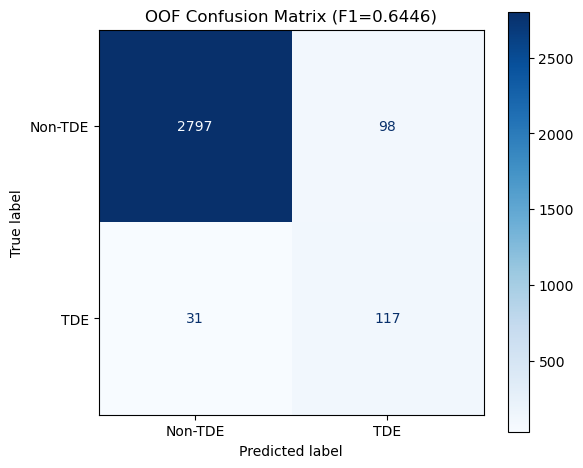

In [16]:
# Classification report & confusion matrix on OOF
print(classification_report(y, oof_pred, target_names=["Non-TDE", "TDE"]))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, oof_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-TDE", "TDE"])
disp.plot(ax=ax, cmap="Blues")
final_f1 = f1_score(y, oof_pred)
ax.set_title(f"OOF Confusion Matrix (F1={final_f1:.4f})")
plt.tight_layout()
plt.show()

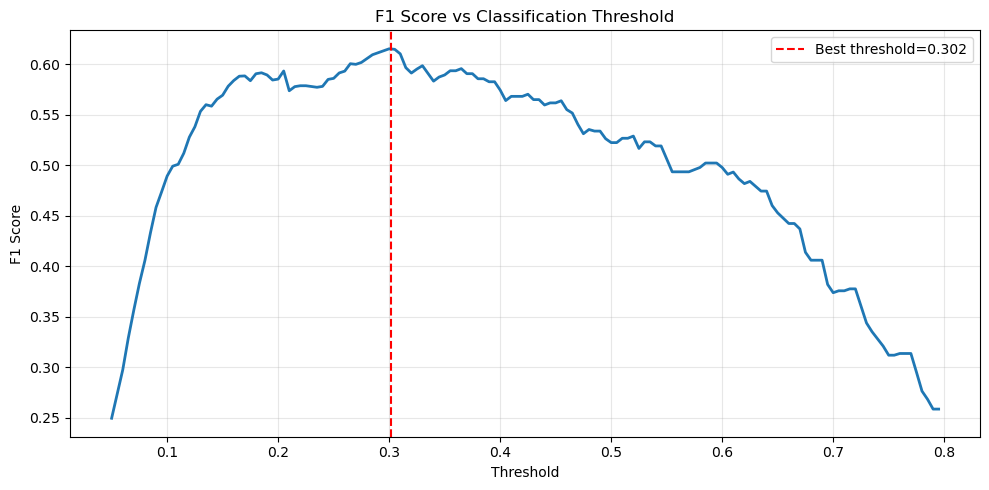

In [17]:
# F1 vs threshold curve
thresholds = np.arange(0.05, 0.8, 0.005)
f1_scores_curve = [f1_score(y, (oof_final >= t).astype(int)) for t in thresholds]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores_curve, linewidth=2)
plt.axvline(best_thr, color="red", linestyle="--", label=f"Best threshold={best_thr:.3f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Importance

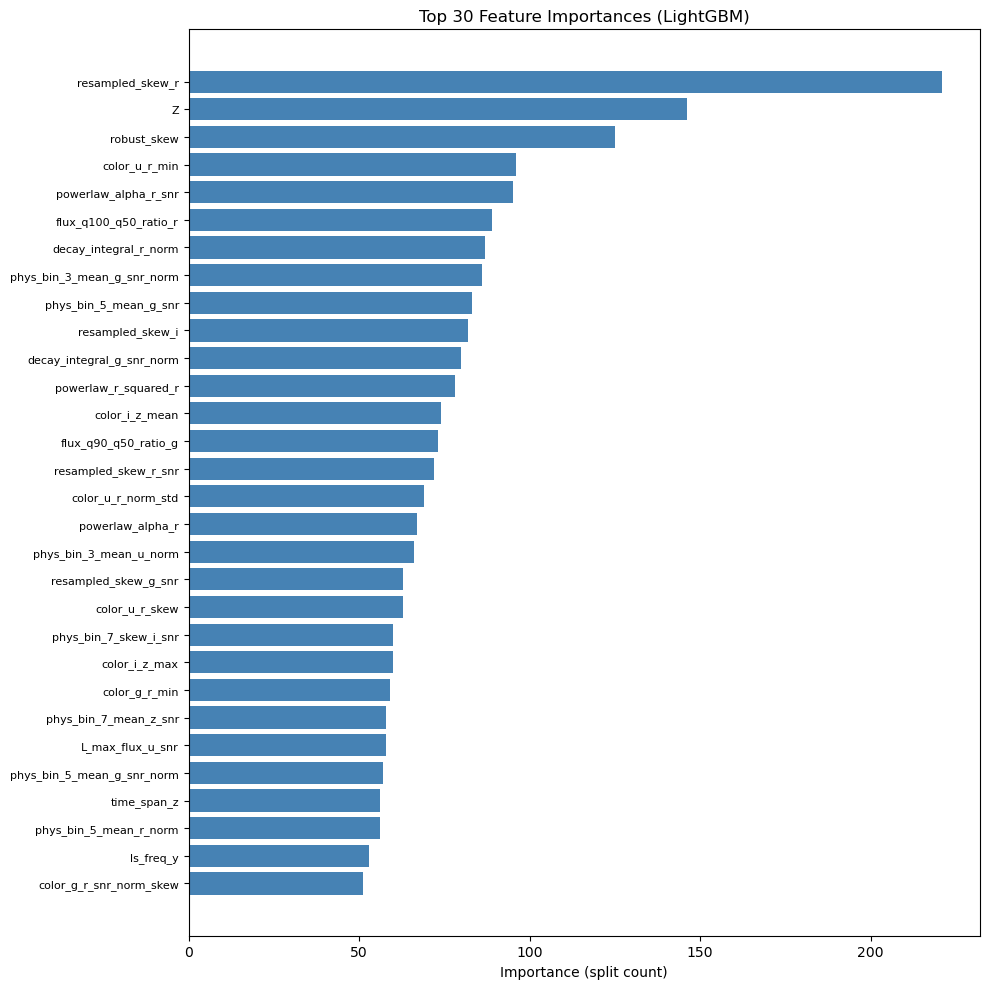


Total features: 825
Features with importance > 0: 814


In [18]:
# Train final LightGBM on all data for feature importance
lgb_params_final = {
    'objective': 'binary', 'metric': 'binary_logloss',
    'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 7,
    'scale_pos_weight': scale_pos, 'verbose': -1, 'n_jobs': -1, 'random_state': 42
}
lgb_full = lgb.LGBMClassifier(**{**lgb_params_final, "n_estimators": 1000})
lgb_full.fit(X, y)

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": lgb_full.feature_importances_
}).sort_values("importance", ascending=False)

# Plot top 30 features
top_n = min(30, len(importance))
top_feats = importance.head(top_n)

plt.figure(figsize=(10, 10))
plt.barh(range(top_n), top_feats["importance"].values[::-1], color="steelblue")
plt.yticks(range(top_n), top_feats["feature"].values[::-1], fontsize=8)
plt.xlabel("Importance (split count)")
plt.title(f"Top {top_n} Feature Importances (LightGBM)")
plt.tight_layout()
plt.show()

print(f"\nTotal features: {len(feature_cols)}")
print(f"Features with importance > 0: {(importance['importance'] > 0).sum()}")

## 8. Generate Submission

In [19]:
# Final prediction on test set
HUGE_DISAGREE = 0.5  # threshold for extreme disagreement rule

if USE_REGIONAL:
    # Calculate test disagreement
    if oof_dl is not None and test_dl is not None:
        test_disagreement = np.abs(test_gbdt_final - test_dl)
    else:
        track_test_preds = list(all_test_preds.values())
        test_diffs = []
        for i in range(len(track_test_preds)):
            for j in range(i+1, len(track_test_preds)):
                test_diffs.append(np.abs(track_test_preds[i] - track_test_preds[j]))
        test_disagreement = np.max(test_diffs, axis=0)

    test_low_mask = test_disagreement < LOW_DIFF_THRESH
    test_mid_mask = (test_disagreement >= LOW_DIFF_THRESH) & (test_disagreement < HIGH_DIFF_THRESH)
    test_high_mask = test_disagreement >= HIGH_DIFF_THRESH

    test_preds = np.zeros(len(X_test), dtype=int)
    for name, mask in [("Low", test_low_mask), ("Mid", test_mid_mask), ("High", test_high_mask)]:
        t = region_thresholds.get(name, best_thr)
        test_preds[mask] = (test_ultimate[mask] >= t).astype(int)
        print(f"  Region {name}: thresh={t:.4f}, positives={test_preds[mask].sum()}")

    # Apply rule arbitration to test (only with DL)
    if oof_dl is not None and test_dl is not None:
        rule_test = (test_disagreement > HUGE_DISAGREE) & (test_preds == 1)
        extreme_test = rule_test & ((test_gbdt_final < 0.05) | (test_dl < 0.05))
        test_preds[extreme_test] = 0
        print(f"  Rule arbitration removed: {extreme_test.sum()} test samples")

    print(f"Regional strategy: Low={test_low_mask.sum()}, Mid={test_mid_mask.sum()}, High={test_high_mask.sum()}")
else:
    test_preds = (test_ultimate >= best_thr).astype(int)
    print(f"Global strategy applied. threshold={best_thr:.4f}")

# SAFETY NET: if zero positive predictions, fall back to top-K
if test_preds.sum() == 0:
    print("\n*** WARNING: All predictions are 0! Falling back to top-K ***")
    expected_pos_rate = y.mean()
    k = max(int(len(test_preds) * expected_pos_rate), 10)
    top_k_indices = np.argsort(test_ultimate)[-k:]
    test_preds[top_k_indices] = 1
    print(f"  Forced top {k} as positive (expected rate: {expected_pos_rate:.2%})")

submission = pd.DataFrame({
    "object_id": test_log["object_id"],
    "prediction": test_preds,
})

# Sanity checks
sample = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert list(submission.columns) == list(sample.columns), "Column mismatch!"
assert len(submission) == len(sample), "Row count mismatch!"

print(f"\nSubmission shape: {submission.shape}")
print(f"Predicted TDEs: {submission['prediction'].sum()} / {len(submission)} ({submission['prediction'].mean():.2%})")
print(f"\nPrediction distribution:")
print(submission["prediction"].value_counts())

output_path = os.path.join(os.path.dirname(DATA_DIR), "submission.csv")
submission.to_csv(output_path, index=False)
print(f"\nSaved to {output_path}")
submission.head(10)

  Region Low: thresh=0.1051, positives=153
  Region Mid: thresh=0.1673, positives=414
  Region High: thresh=0.3017, positives=36
Regional strategy: Low=6092, Mid=985, High=58

Submission shape: (7135, 2)
Predicted TDEs: 603 / 7135 (8.45%)

Prediction distribution:
prediction
0    6532
1     603
Name: count, dtype: int64

Saved to C:\Users\SG\Downloads\mallorn-astronomical-classification-challenge\submission.csv


,object_id,prediction
0,Eluwaith_Mithrim_nothrim,0
1,Eru_heledir_archam,0
2,Gonhir_anann_fuin,0
3,Gwathuirim_haradrim_tegilbor,0
4,achas_minai_maen,0
5,adab_fae_gath,0
6,adel_draug_gaur,0
7,aderthad_cuil_galadhrim,1
8,aegas_laug_ithildin,0
9,aegas_mereth_law,0
